# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [1]:
import pandas as pd
import numpy as np

now i will load that placement.csv data

In [13]:
df = pd.read_csv('/content/placement.csv')

In [14]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


* as we can see there is no null values.
* but there is an extra column we have to remove that Unnamed column
* so my task is to remove that column

If you run `df = df.iloc[:,1:]` command multiple times, that will remove all columns from your DataFrame. Let's reload the data and then remove the 'Unnamed: 0' column correctly.

In [16]:
df = df.iloc[:,1:]

In [17]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


now we can clearly see that first column in removed and now we will see that data visually by matplotlib

In [18]:
import matplotlib.pyplot as plt


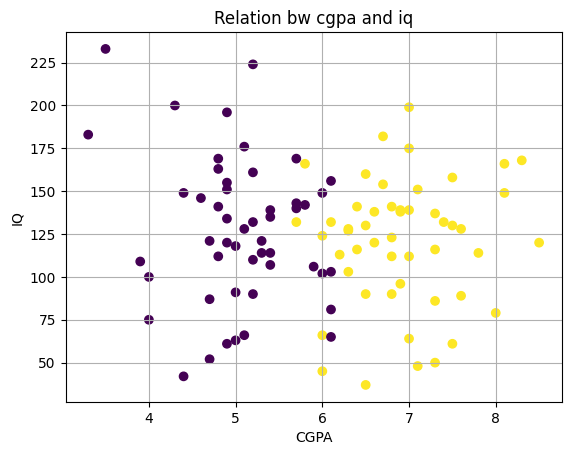

In [26]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

plt.title("Relation bw cgpa and iq")
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.grid(linestyle='-')
plt.show()

Now we want to apply logistic regression model in that dataset and draw a boundary between those two. this is a classification problem with this dataset we will train a model split the data then check it that if it is able to predict that some student can get placement or not first we train on 90 points and then we will check on 10 test data points and check our accuracy if our accuracy is good more than 90% then model is performing good.

In [28]:
X=df.iloc[:,0:2]
y=df.iloc[:,2]

print(X.head())
print(y.shape)

   cgpa     iq
0   6.8  123.0
1   5.9  106.0
2   5.3  121.0
3   7.4  132.0
4   5.8  142.0
(100,)


In [37]:
# now i will try to split the data for that task i will use sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

# i store the values in four different variables

now we are doing scaling it is not compulsary but we are doing it , coz it is a good practice..

In [39]:
from sklearn.preprocessing import StandardScaler


In [41]:
scaler = StandardScaler()


In [42]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
X_test

array([[-0.90148238, -1.54710014],
       [ 0.25249397, -0.52007441],
       [-0.01380826, -1.47007321],
       [ 0.96263326,  0.71235645],
       [ 2.0278422 ,  1.14884239],
       [-1.25655203,  0.58397824],
       [-0.72394756,  2.5866784 ],
       [ 0.07495915, -0.52007441],
       [-0.72394756,  0.22451923],
       [-1.87792391, -0.36602056]])

In [45]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [46]:
# model training
clf.fit(X_train, y_train)

LogisticRegression()

now evaluate the model

In [50]:
y_pred = clf.predict(X_test)
y_pred

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 0])

In [48]:
y_test

,placement
7,0
98,1
45,1
21,1
53,1
39,0
16,0
14,0
19,0
31,0


In [51]:
# now i just have to compare the prediction of my model and actual y_test
from sklearn.metrics import accuracy_score


In [52]:
accuracy_score(y_test, y_pred)

0.8

Now i am just seeing how can we visualize the decision boundary

In [53]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

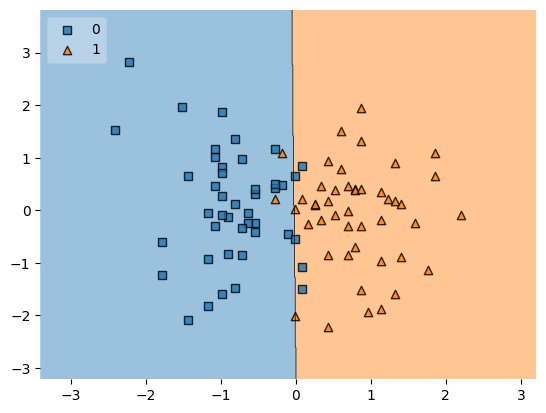

In [55]:
# i don't write X_train.values because i already scale that X
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [60]:
# after that in my content folder a new file model.pkl will be created that's my model if i satisfied with it i can deploy it on aws, azure or heroku
import pickle

In [59]:
pickle.dump(clf,open('model.pkl','wb'))
